In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# Function to plot metrics
def plot_metric(y_values, ylabel, title):
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, y_values, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()
def plot_trainNval_metric(y_values_train, y_values_val, ylabel, title):
    plt.figure(figsize=(5, 3))
    plt.plot(epochs, y_values_train, marker='o', label="train")
    plt.plot(epochs, y_values_val, marker='o', label="val")
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
def plot_trainNvalNtest_metric(y_values_train, y_values_val, y_values_test, ylabel, title):
    plt.figure(figsize=(5, 3))
    plt.plot(epochs, y_values_train, marker='o', label="train")
    plt.plot(epochs, y_values_val, marker='o', label="val")
    plt.plot(epochs, y_values_test, marker='o', label="test")
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [25]:
def get_metrics(file, metrics):
    epochs = []
    with open(log_file, 'r') as f:
        for line in f:
            entry = json.loads(line.strip())  # Parse each line as JSON
            epochs.append(entry['epoch'])
            metrics['train_loss'].append(entry['train_loss'])
            metrics['val_loss'].append(entry['val_loss'])
            metrics['test_loss'].append(entry['test_loss'])
            metrics['train_class_acc'].append(entry['train_class_acc'])
            metrics['val_accuracy'].append(entry['val_accuracy'])
            metrics['test_accuracy'].append(entry['test_accuracy'])
            metrics['val_roc_auc'].append(entry['val_roc_auc'])
            metrics['test_roc_auc'].append(entry['test_roc_auc'])
            metrics['test_balanced_accuracy'].append(entry['test_balanced_accuracy'])
            metrics['test_auc_pr'].append(entry['test_pr_auc'])
    return metrics, epochs
    

max test balanced acc: 0.8764396728591102
best epoch: 4


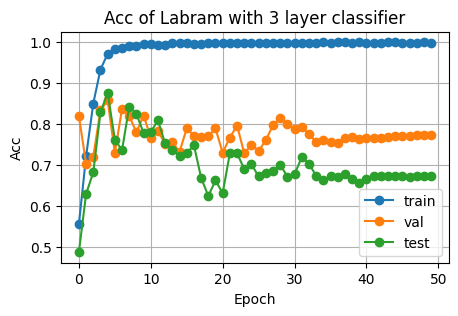

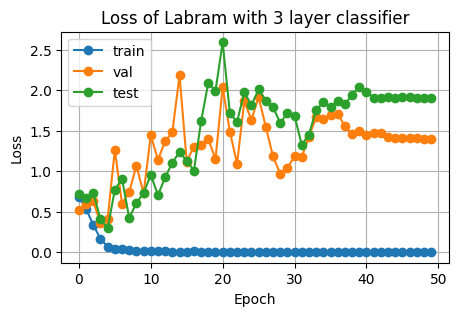

In [29]:
log_file = f'/work/HHRI-AI/YW/Yirong/LaBramFinetune/checkpoints/finetune_stress_noleak_30chan_no400up_seed_siwen42-4review-cbramod3lyclassifier/log.txt'

metrics = {
    'train_loss': [], 'val_loss': [], 'test_loss': [],
    'train_class_acc': [], 'val_accuracy': [], 'test_accuracy': [],
    'val_roc_auc': [], 'test_roc_auc': [], 'test_balanced_accuracy':[],
    'test_auc_pr':[]
}

metrics, epochs = get_metrics(log_file, metrics)

epoch_id = np.argmax(metrics['test_balanced_accuracy'])
print(f"max test balanced acc: {max(metrics['test_balanced_accuracy'])}")
print(f"best epoch: {epoch_id}")

plot_trainNvalNtest_metric(metrics['train_class_acc'], metrics['val_accuracy'], metrics['test_balanced_accuracy'], 'Acc', 'Acc of Labram with 3 layer classifier')
plot_trainNvalNtest_metric(metrics['train_loss'], metrics['val_loss'], metrics['test_loss'], 'Loss', 'Loss of Labram with 3 layer classifier')

max test balanced acc: 0.9165003794159805
best epoch: 5


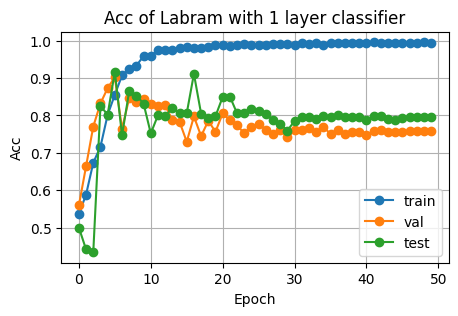

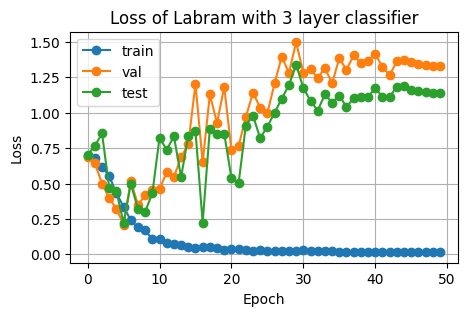

In [30]:
log_file = f'/work/HHRI-AI/YW/Yirong/LaBramFinetune/checkpoints/finetune_stress_noleak_30chan_no400up_seed_siwen42-4review-default/log.txt'

metrics = {
    'train_loss': [], 'val_loss': [], 'test_loss': [],
    'train_class_acc': [], 'val_accuracy': [], 'test_accuracy': [],
    'val_roc_auc': [], 'test_roc_auc': [], 'test_balanced_accuracy':[],
    'test_auc_pr':[]
}

metrics, epochs = get_metrics(log_file, metrics)

epoch_id = np.argmax(metrics['test_balanced_accuracy'])
print(f"max test balanced acc: {max(metrics['test_balanced_accuracy'])}")
print(f"best epoch: {epoch_id}")

plot_trainNvalNtest_metric(metrics['train_class_acc'], metrics['val_accuracy'], metrics['test_balanced_accuracy'], 'Acc', 'Acc of Labram with 1 layer classifier')
plot_trainNvalNtest_metric(metrics['train_loss'], metrics['val_loss'], metrics['test_loss'], 'Loss', 'Loss of Labram with 3 layer classifier')

---

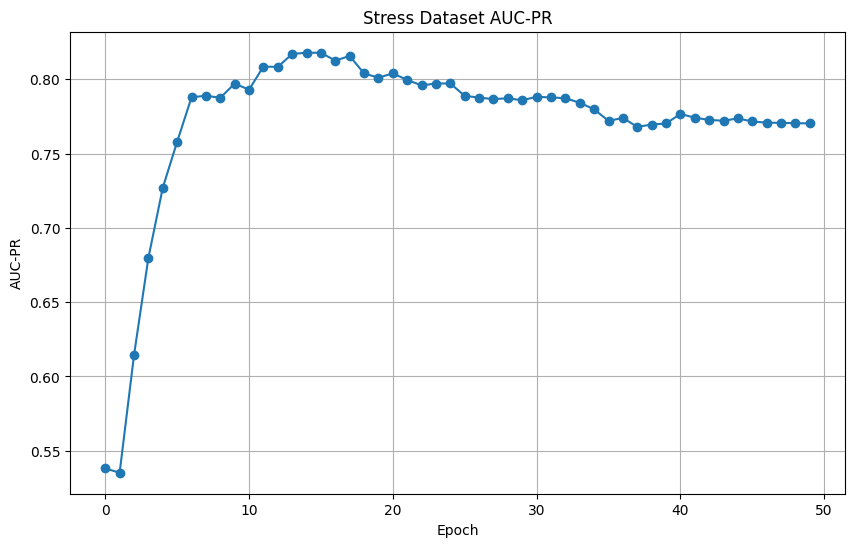

In [7]:
plot_metric(metrics['test_auc_pr'], 'AUC-PR', 'Stress Dataset AUC-PR')


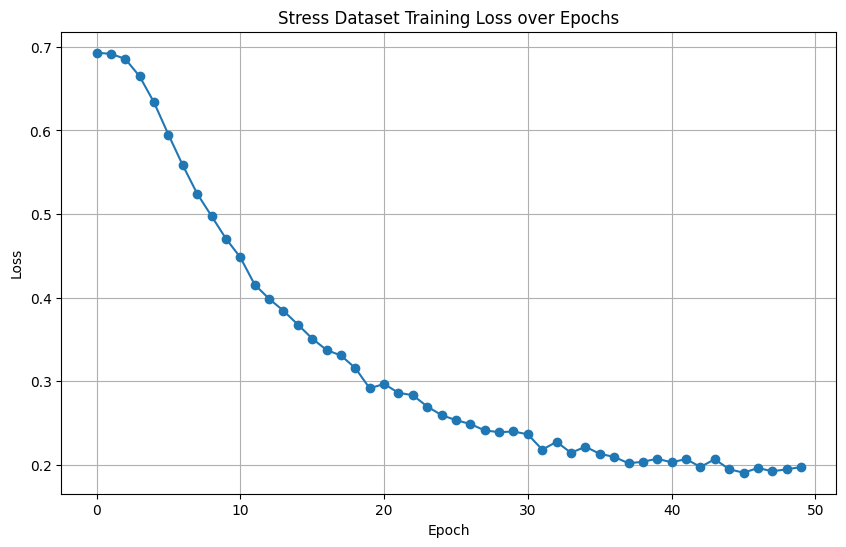

Minimum Loss:  0.19028395754330366
Minimum loss on epoch:  45


In [4]:
plot_metric(metrics['train_loss'], 'Loss', 'Stress Dataset Training Loss over Epochs')
min_train_loss=min(metrics['train_loss'])
print("Minimum Loss: ", min_train_loss)
print("Minimum loss on epoch: ", metrics['train_loss'].index(min_train_loss))

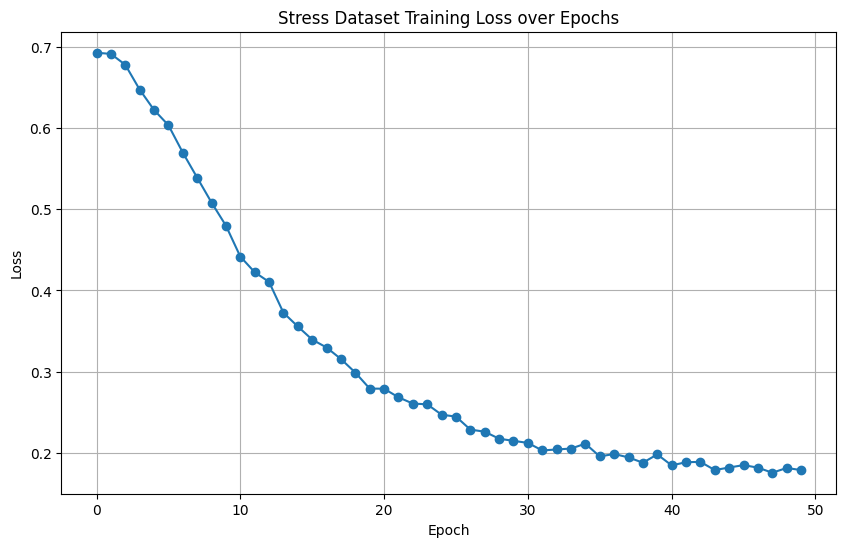

Minimum Loss:  0.17531812952747985
Minimum loss on epoch:  47


In [8]:
plot_metric(metrics['train_loss'], 'Loss', 'Stress Dataset Training Loss over Epochs')
min_train_loss=min(metrics['train_loss'])
print("Minimum Loss: ", min_train_loss)
print("Minimum loss on epoch: ", metrics['train_loss'].index(min_train_loss))

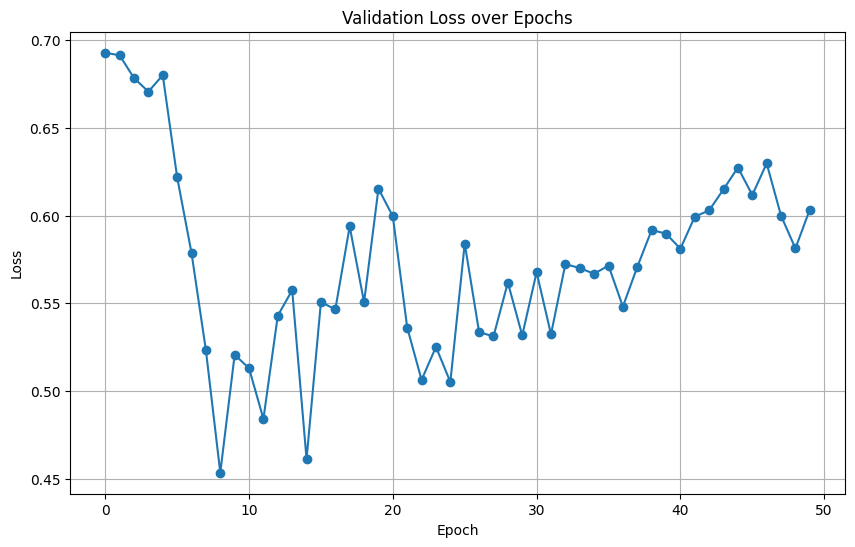

Minimum Loss:  0.4534652791917324
Minimum loss on epoch:  8


In [5]:
plot_metric(metrics['val_loss'], 'Loss', 'Validation Loss over Epochs')
min_val_loss=min(metrics['val_loss'])
print("Minimum Loss: ", min_val_loss)
print("Minimum loss on epoch: ", metrics['val_loss'].index(min_val_loss))

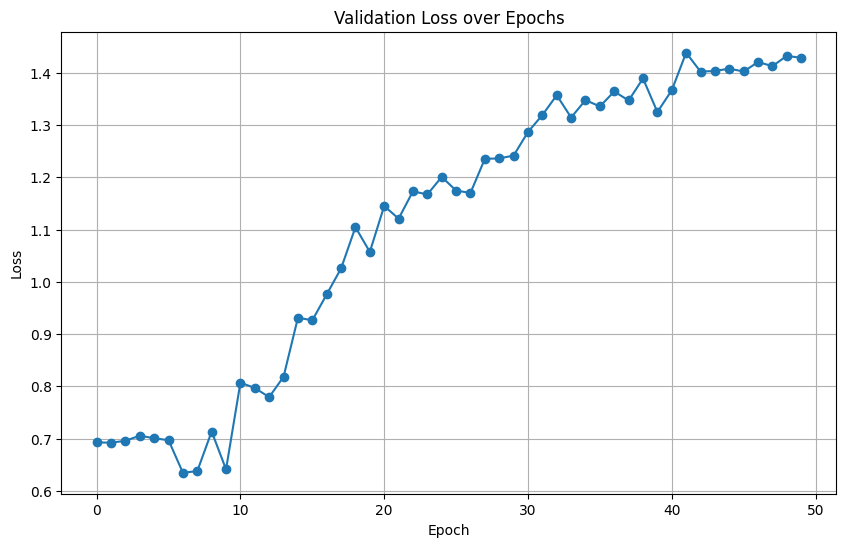

Minimum Loss:  0.634697459245983
Minimum loss on epoch:  6


In [9]:
plot_metric(metrics['val_loss'], 'Loss', 'Validation Loss over Epochs')
min_val_loss=min(metrics['val_loss'])
print("Minimum Loss: ", min_val_loss)
print("Minimum loss on epoch: ", metrics['val_loss'].index(min_val_loss))

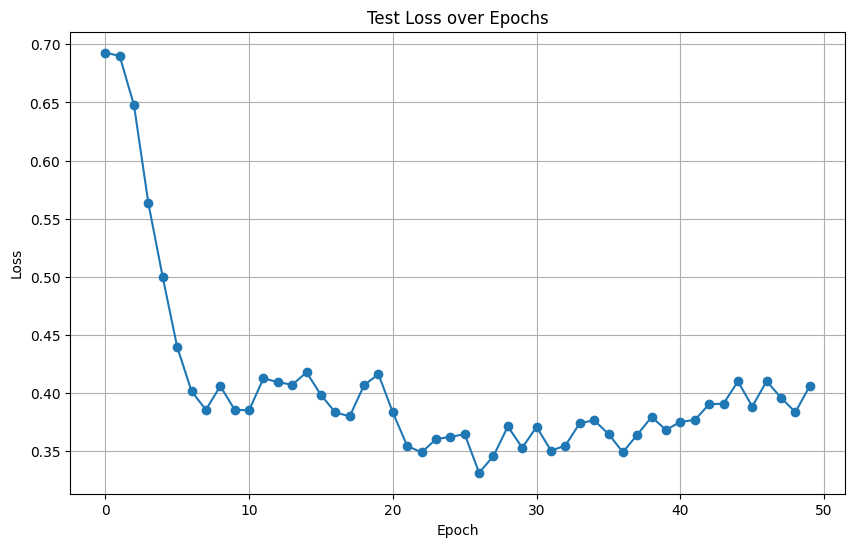

Minimum Loss:  0.33134772181510924
Minimum loss on epoch:  26


In [6]:
plot_metric(metrics['test_loss'], 'Loss', 'Test Loss over Epochs')
min_val_loss=min(metrics['test_loss'])
print("Minimum Loss: ", min_val_loss)
print("Minimum loss on epoch: ", metrics['test_loss'].index(min_val_loss))

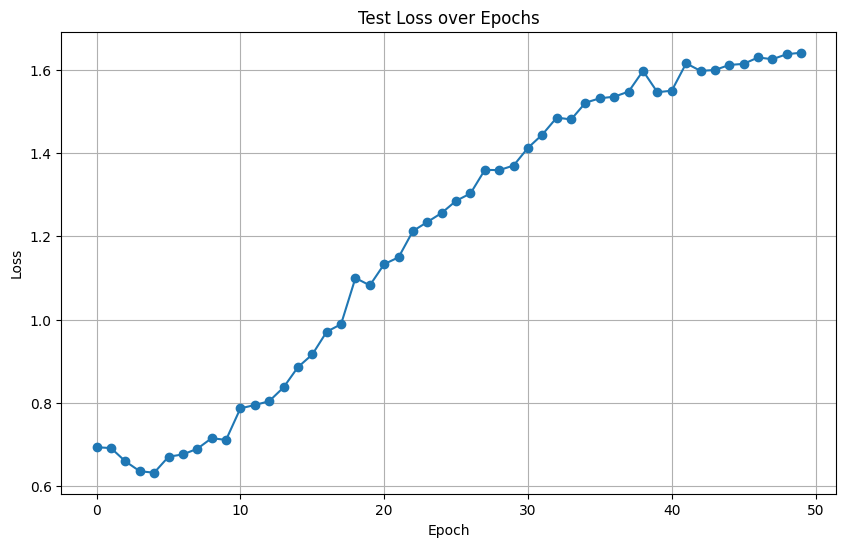

Minimum Loss:  0.6314248726481483
Minimum loss on epoch:  4


In [10]:
plot_metric(metrics['test_loss'], 'Loss', 'Test Loss over Epochs')
min_val_loss=min(metrics['test_loss'])
print("Minimum Loss: ", min_val_loss)
print("Minimum loss on epoch: ", metrics['test_loss'].index(min_val_loss))

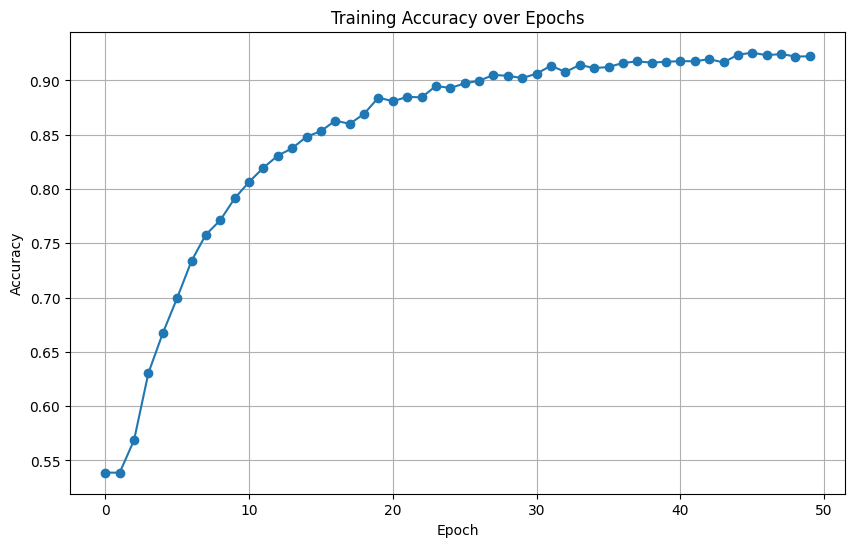

Max accuracy:  0.9255157766990292
Minimum loss on epoch:  45


In [7]:
plot_metric(metrics['train_class_acc'], 'Accuracy', 'Training Accuracy over Epochs')
max_acc=max(metrics['train_class_acc'])
print("Max accuracy: ", max_acc)
print("Minimum loss on epoch: ", metrics['train_class_acc'].index(max_acc))

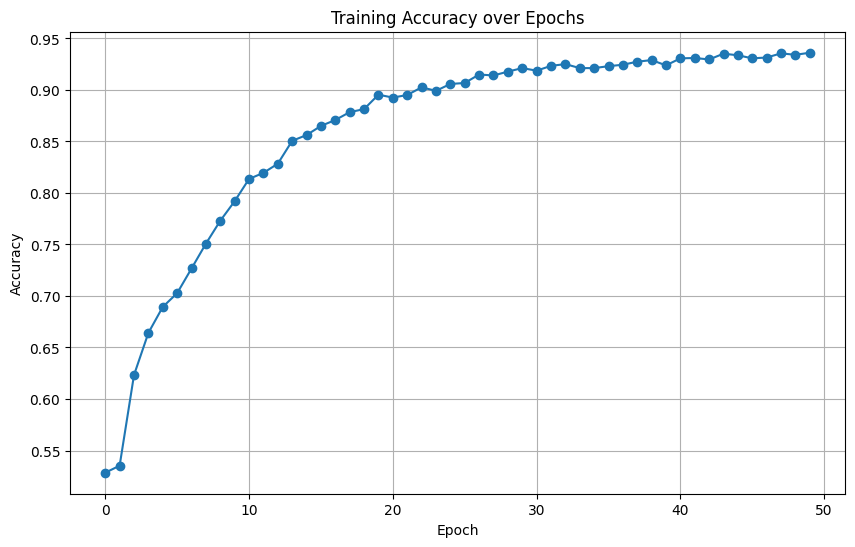

Max accuracy:  0.9361007462686567
Minimum loss on epoch:  49


In [11]:
plot_metric(metrics['train_class_acc'], 'Accuracy', 'Training Accuracy over Epochs')
max_acc=max(metrics['train_class_acc'])
print("Max accuracy: ", max_acc)
print("Minimum loss on epoch: ", metrics['train_class_acc'].index(max_acc))

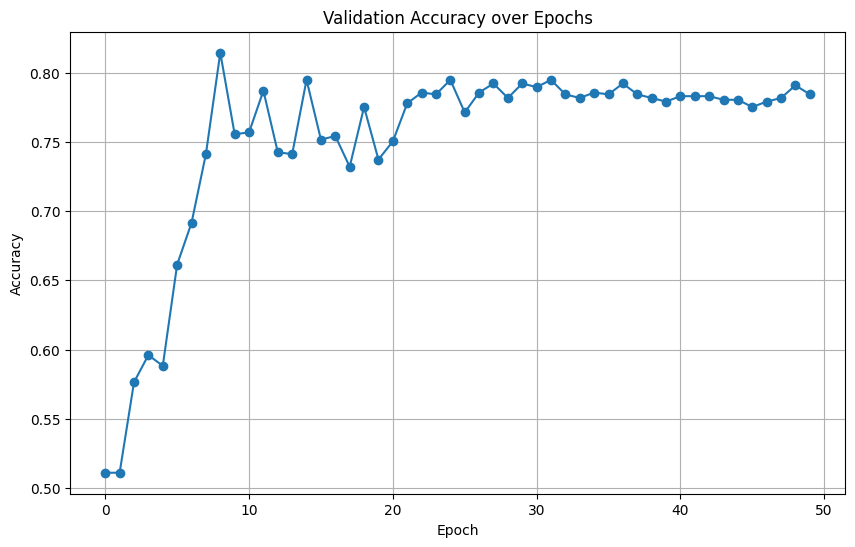

Max accuracy:  0.8143790849673203
Minimum loss on epoch:  8


In [8]:
plot_metric(metrics['val_accuracy'], 'Accuracy', 'Validation Accuracy over Epochs')
max_acc=max(metrics['val_accuracy'])
print("Max accuracy: ", max_acc)
print("Minimum loss on epoch: ", metrics['val_accuracy'].index(max_acc))

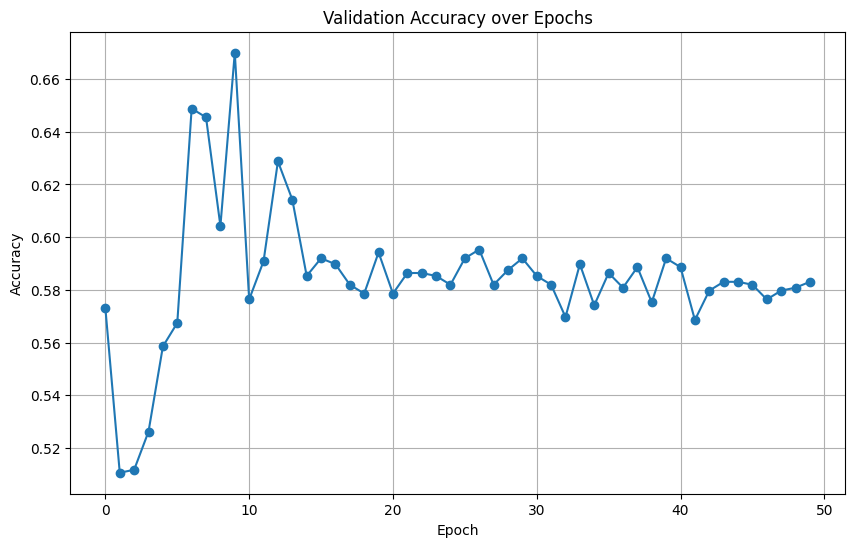

Max accuracy:  0.6700111482720178
Minimum loss on epoch:  9


In [12]:
plot_metric(metrics['val_accuracy'], 'Accuracy', 'Validation Accuracy over Epochs')
max_acc=max(metrics['val_accuracy'])
print("Max accuracy: ", max_acc)
print("Minimum loss on epoch: ", metrics['val_accuracy'].index(max_acc))

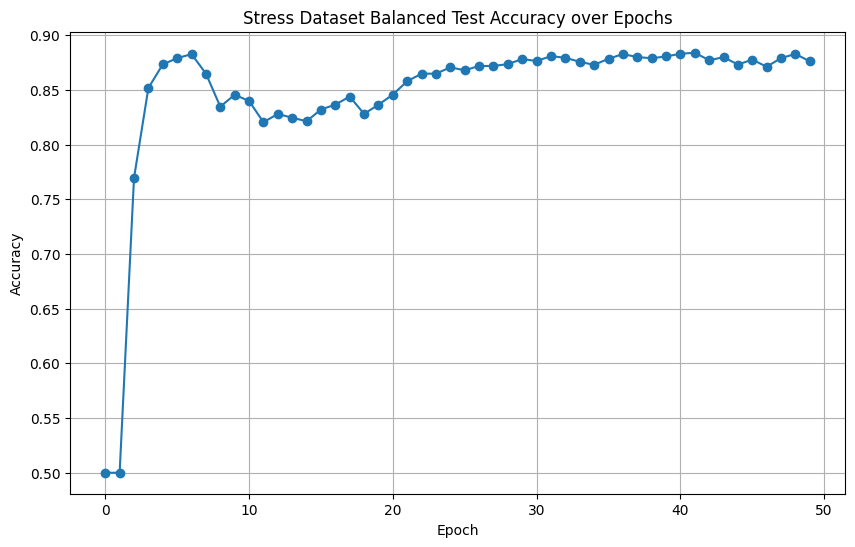

Max accuracy:  0.8841154146272256
Minimum loss on epoch:  41


In [9]:
plot_metric(metrics['test_balanced_accuracy'], 'Accuracy', 'Stress Dataset Balanced Test Accuracy over Epochs')
max_acc=max(metrics['test_balanced_accuracy'])
print("Max accuracy: ", max_acc)
print("Minimum loss on epoch: ", metrics['test_balanced_accuracy'].index(max_acc))


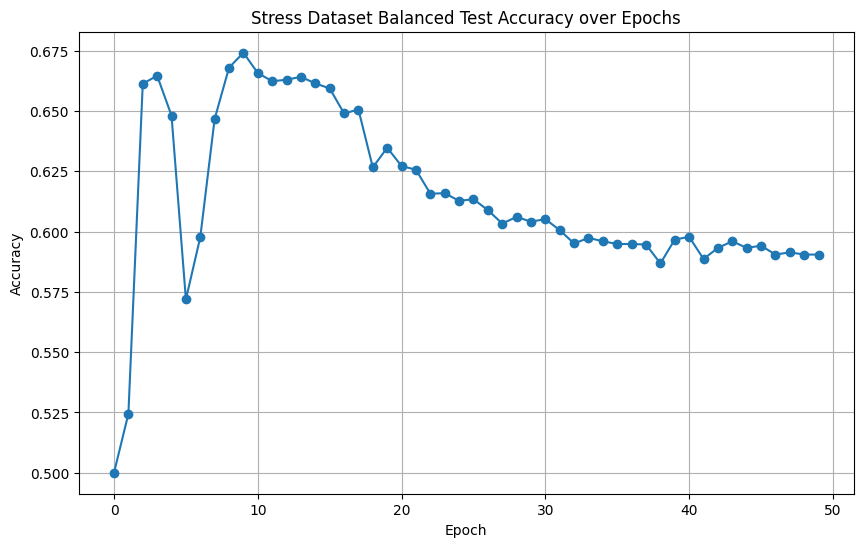

Max accuracy:  0.6742238562091503
Minimum loss on epoch:  9


In [13]:
plot_metric(metrics['test_balanced_accuracy'], 'Accuracy', 'Stress Dataset Balanced Test Accuracy over Epochs')
max_acc=max(metrics['test_balanced_accuracy'])
print("Max accuracy: ", max_acc)
print("Minimum loss on epoch: ", metrics['test_balanced_accuracy'].index(max_acc))


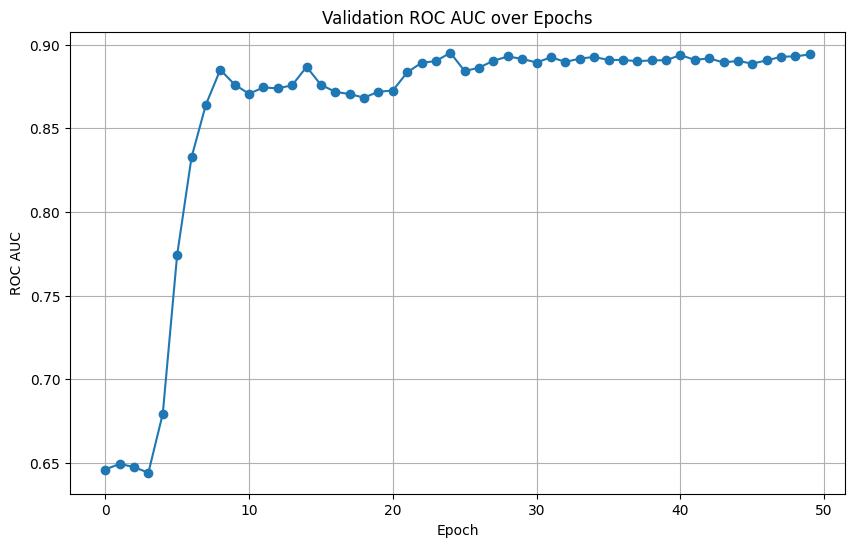

In [10]:
plot_metric(metrics['val_roc_auc'], 'ROC AUC', 'Validation ROC AUC over Epochs')


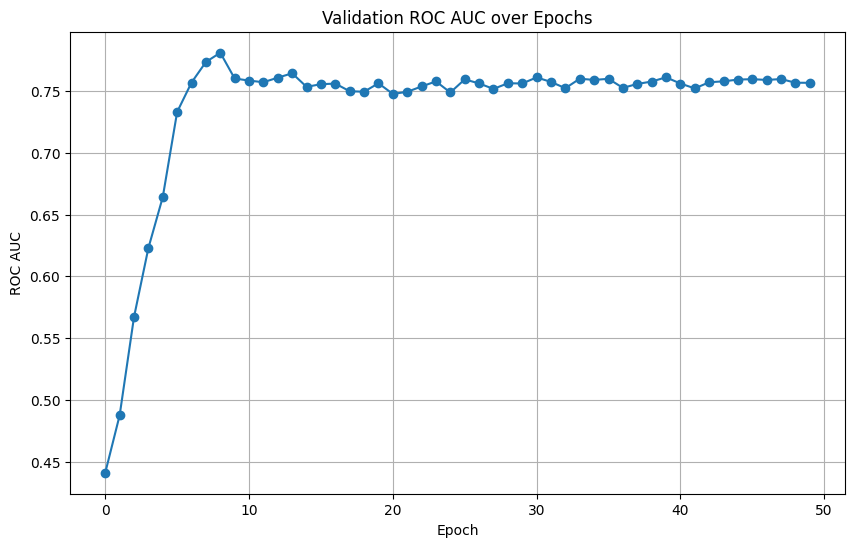

In [14]:
plot_metric(metrics['val_roc_auc'], 'ROC AUC', 'Validation ROC AUC over Epochs')


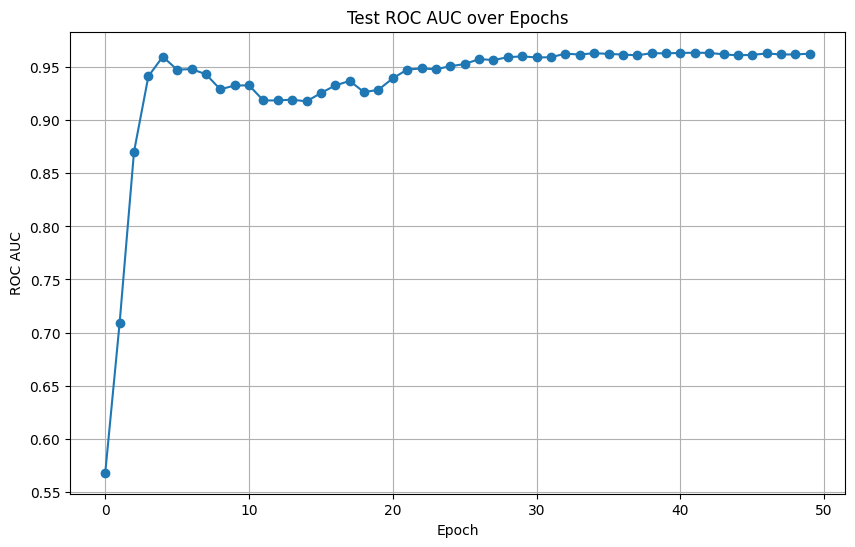

In [11]:
plot_metric(metrics['test_roc_auc'], 'ROC AUC', 'Test ROC AUC over Epochs')

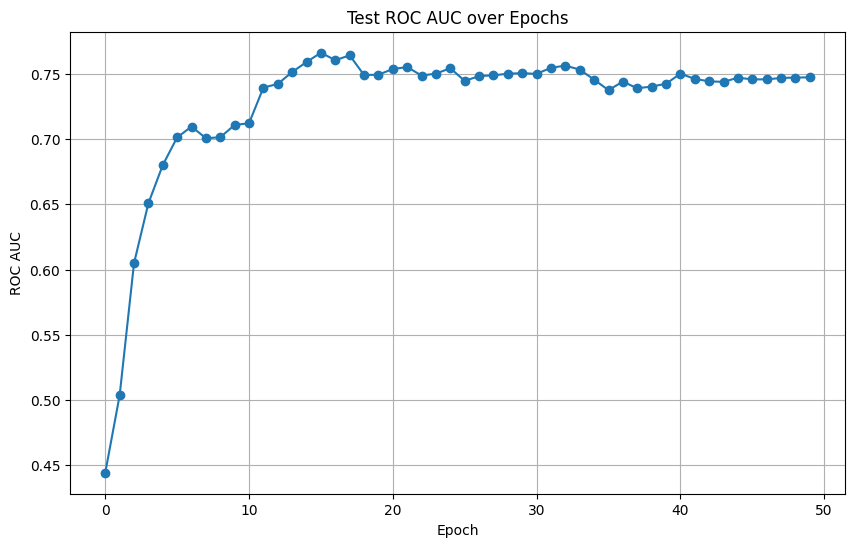

In [15]:
plot_metric(metrics['test_roc_auc'], 'ROC AUC', 'Test ROC AUC over Epochs')